In [1]:
%load_ext autoreload

%autoreload 2

## dataset

In [2]:
from pathlib import Path

In [3]:
from src.dataset import S2TIFDataSet

In [4]:
from src.misc import select_patches_from_dataset

In [5]:
file_paths = select_patches_from_dataset("./data/cloudsen12_initial_cloudfree_dev_1000.csv", "./data")

In [6]:
len(file_paths)

1000

In [7]:
USER = "di54xat"
ROOT_HPC = Path("/dss/dsstbyfs02/pn49ci/pn49ci-dss-0026")
USER_PATH = ROOT_HPC / f"{USER}"
DATA_PATH_HPC = ROOT_HPC / "cloudsen12" / "data"

ROOT_LOCAL = Path("$HOME/projects/ai_course")
DATA_PATH_LOCAL = ROOT_LOCAL / "data"

USE_HPC = True

if USE_HPC:
    ROOT = ROOT_HPC
    DATA_PATH = DATA_PATH_HPC
else:
    ROOT = ROOT_LOCAL
    DATA_PATH = DATA_PATH_LOCAL

DATA_ROOT = DATA_PATH

In [8]:
DATA_PATH

PosixPath('/dss/dsstbyfs02/pn49ci/pn49ci-dss-0026/cloudsen12/data')

In [9]:
from torch.utils.data import DataLoader

In [24]:
import tifffile
import torchvision.transforms.functional as TF


### check img shape

In [25]:
img = tifffile.imread(train_dataset.img_paths[0])

X = TF.to_tensor(img)

In [26]:
img.shape

(509, 509, 15)

In [ ]:
X.shape # should be ok

torch.Size([15, 509, 509])

### load data into dataloader

In [29]:

# Train/val split (80/20)
split_idx = int(0.8 * len(file_paths))
train_names = file_paths[:split_idx]
val_names = file_paths[split_idx:]


# Create datasets and dataloaders
train_dataset = S2TIFDataSet(train_names, DATA_ROOT)
val_dataset = S2TIFDataSet(val_names, DATA_ROOT)

train_loader = DataLoader(
    train_dataset,
    batch_size=12,
    shuffle=True,
    num_workers=16,
    prefetch_factor=8,
    drop_last=True,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=16,
    prefetch_factor=8,
    pin_memory=True,
)

/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [30]:
len(train_dataset)

800

661


TypeError: 'float' object is not subscriptable

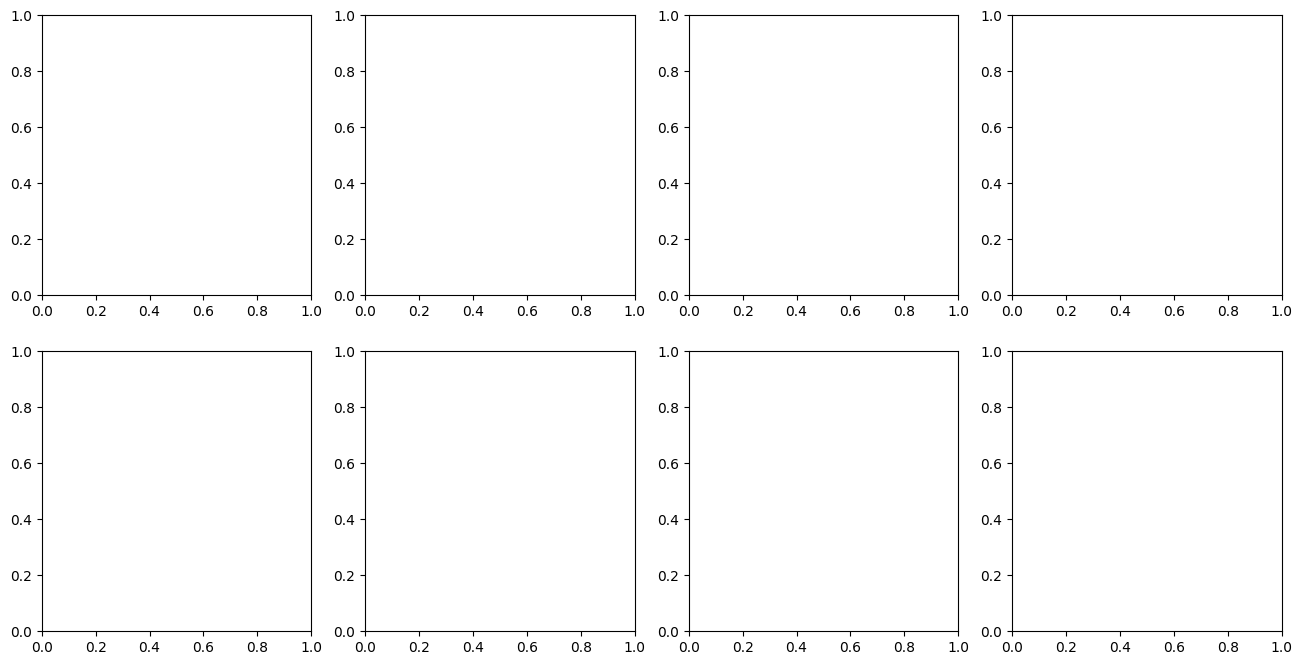

In [31]:
# check what the loader loads
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    rand_id = int(random.random() * len(train_dataset))
    print(rand_id)
    sample_x, sample_y = train_dataset[rand_id]

    # Plot input
    axes[0, i].imshow(sample_x.squeeze(), cmap="gray")
    axes[0, i].axis("off")

    # Plot target
    im = axes[1, i].imshow(sample_y.numpy(), cmap="tab10", vmin=0, vmax=2)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## model init

## training

## validation